# IN4640 — Assignment 02 (Fitting & Alignment)

This notebook produces **all required outputs** for:
1) **Total Least Squares** line fit (first line only)  
2) **RANSAC** multi-line fitting (3 lines)  
3) **Earring size estimation** using camera geometry  
4) **Flag overlay on cricket turf** using homography

**Inputs (already placed in this folder):**
- `lines.csv`
- `earrings.jpg`
- `turf.jpg`

> Replace any placeholders (e.g., flag image path, clicked points) and run the notebook top-to-bottom.


In [ ]:
%pip install numpy matplotlib scikit-learn opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   --- ------------------------------------ 3.1/40.2 MB 28.9 MB/s eta 0:00:02
   --------- ------------------------------ 9.4/40.2 MB 30.5 MB/s eta 0:00:02
   --------------- ------------------------ 15.7/40.2 MB 30.7 MB/s eta 0:00:01
   --------------------- ------------------ 22.0/40.2 MB 31.0 MB/s eta 0:00:01
   ------------------------------- -------- 31.2/40.2 MB 33.9 MB/s eta 0:00:01
   ------------------------------------- -- 37.7/40.2 MB 33.0 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 30.5 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.linear_model import RANSACRegressor
from pathlib import Path

BASE = Path('.')
LINES_CSV    = BASE / "Resources" / "lines.csv"
EARRINGS_IMG = BASE / "Resources" / "earrings.jpg"
TURF_IMG     = BASE / "Resources" / "turf.jpg"

print('Files exist:')
print('lines.csv:', LINES_CSV.exists())
print('earrings.jpg:', EARRINGS_IMG.exists())
print('turf.jpg:', TURF_IMG.exists())


Files exist:
lines.csv: True
earrings.jpg: True
turf.jpg: True


## 1(a) Total Least Squares (TLS) — Fit only the first line (x1, y1)

We fit the line in implicit form:

\[ ax + by + c = 0 \]

TLS finds the normal vector \([a, b]\) as the eigenvector associated with the **smallest eigenvalue** of the scatter matrix of centered points.

In [ ]:
# Load data
D = np.genfromtxt(LINES_CSV, delimiter=',', skip_header=1)

x1 = D[:, 0]
y1 = D[:, 3]
P = np.column_stack([x1, y1])

# TLS
centroid = P.mean(axis=0)
Q = P - centroid
C = Q.T @ Q  # 2x2 scatter matrix

eigvals, eigvecs = np.linalg.eig(C)
normal = eigvecs[:, np.argmin(eigvals)]  # [a, b]
a, b = normal
c = -(a*centroid[0] + b*centroid[1])

# normalize for nicer printing
norm = np.sqrt(a*a + b*b)
a, b, c = a/norm, b/norm, c/norm

print('TLS line parameters (implicit):')
print(f'a={a:.6f}, b={b:.6f}, c={c:.6f}')


TLS line parameters (implicit):
a=-0.773562, b=0.633721, c=3.794192


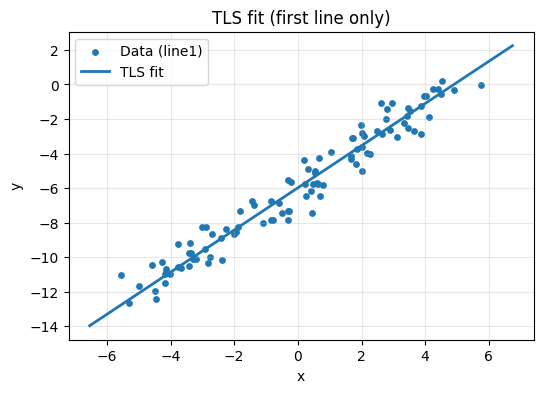

In [ ]:
# Plot TLS result
xmin, xmax = x1.min()-1, x1.max()+1
xs = np.linspace(xmin, xmax, 200)

if abs(b) > 1e-9:
    ys = (-a*xs - c)/b
    plt.figure(figsize=(6,4))
    plt.scatter(x1, y1, s=15, label='Data (line1)')
    plt.plot(xs, ys, linewidth=2, label='TLS fit')
    plt.xlabel('x'); plt.ylabel('y'); plt.title('TLS fit (first line only)')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('b is ~0; vertical line case. x = constant.')


### Placeholder — Put this TLS plot into your report

**[FIGURE 1: TLS line fit plot HERE]**

## 1(b) Fit three lines using RANSAC (mask inliers and repeat)

We flatten the 3 columns of x and y to one set of points and repeatedly run RANSAC three times:
1) fit a line, collect inliers
2) remove inliers
3) repeat to get 3 lines.

In [ ]:
# Prepare all points
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten().reshape(-1, 1)
Y_all = Y_cols.flatten()

remaining_X = X_all.copy()
remaining_Y = Y_all.copy()

lines = []
inlier_sets = []

for k in range(3):
    ransac = RANSACRegressor(
        min_samples=2,
        residual_threshold=None,
        random_state=42+k
    )
    ransac.fit(remaining_X, remaining_Y)
    inlier_mask = ransac.inlier_mask_
    
    m = float(ransac.estimator_.coef_[0])
    b0 = float(ransac.estimator_.intercept_)
    lines.append((m, b0))
    inlier_sets.append((remaining_X[inlier_mask].copy(), remaining_Y[inlier_mask].copy()))
    
    remaining_X = remaining_X[~inlier_mask]
    remaining_Y = remaining_Y[~inlier_mask]

print('Detected lines (y = m x + b):')
for i, (m, b0) in enumerate(lines, 1):
    print(f'Line {i}: y = {m:.6f} x + {b0:.6f}')
print('Remaining points after 3 fits:', len(remaining_X))


Detected lines (y = m x + b):
Line 1: y = -0.463283 x + 1.944594
Line 2: y = -0.153271 x + -3.327881
Line 3: y = 2.071539 x + -3.581040
Remaining points after 3 fits: 14


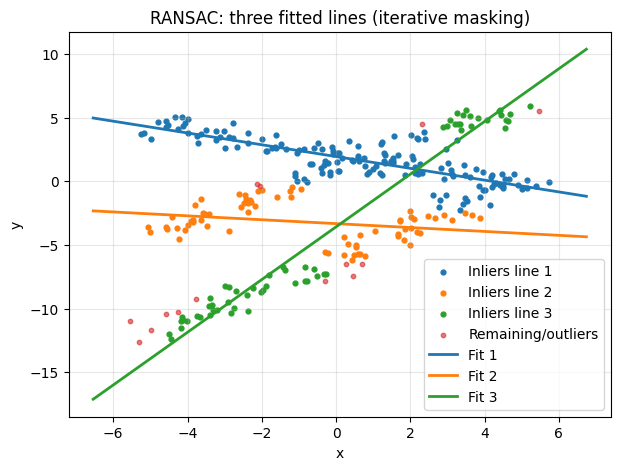

In [ ]:
# Plot RANSAC results
plt.figure(figsize=(7,5))

for i, (Xi, Yi) in enumerate(inlier_sets, 1):
    plt.scatter(Xi.flatten(), Yi, s=12, label=f'Inliers line {i}')

if len(remaining_X) > 0:
    plt.scatter(remaining_X.flatten(), remaining_Y, s=10, label='Remaining/outliers', alpha=0.6)

xs = np.linspace(X_all.min()-1, X_all.max()+1, 200)
for i, (m, b0) in enumerate(lines, 1):
    plt.plot(xs, m*xs + b0, linewidth=2, label=f'Fit {i}')

plt.xlabel('x'); plt.ylabel('y')
plt.title('RANSAC: three fitted lines (iterative masking)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Placeholder — Put this RANSAC plot into your report

**[FIGURE 2: RANSAC three lines plot HERE]**

## 2) Earring size estimation from camera geometry

Given:
- focal length **f = 8 mm**
- pixel size **p = 2.2 μm = 0.0022 mm**
- distance to object plane **Z = 720 mm**

Object size per pixel:
\[ \text{mm/px} = (Z/f) \cdot p \]

Then:
\[ \text{Object size (mm)} = \text{pixel length} \times \text{mm/px} \]

Below you can measure the earring diameter in pixels using OpenCV (click two points).

In [ ]:
# Compute mm per pixel
f_mm = 8.0
Z_mm = 720.0
pixel_mm = 0.0022

mm_per_px = (Z_mm / f_mm) * pixel_mm
print('mm_per_px =', mm_per_px)
print('=> each pixel corresponds to', mm_per_px, 'mm on the object plane')


mm_per_px = 0.198
=> each pixel corresponds to 0.198 mm on the object plane


In [ ]:
# OPTIONAL interactive measurement (click two points on one earring diameter)
# Click point 1 and point 2, then press any key.

img = cv2.imread(str(EARRINGS_IMG))
if img is None:
    raise FileNotFoundError('earrings.jpg not found')

display = img.copy()
pts = []

def cb(event, x, y, flags, param):
    global pts, display
    if event == cv2.EVENT_LBUTTONDOWN and len(pts) < 2:
        pts.append((x,y))
        cv2.circle(display, (x,y), 6, (0,0,255), -1)
        cv2.imshow('earrings', display)

cv2.namedWindow('earrings')
cv2.setMouseCallback('earrings', cb)
cv2.imshow('earrings', display)
cv2.waitKey(0)
cv2.destroyAllWindows()

if len(pts) == 2:
    (x1,y1),(x2,y2) = pts
    px_dist = ((x1-x2)**2 + (y1-y2)**2)**0.5
    size_mm = px_dist * mm_per_px
    print('Clicked points:', pts)
    print(f'Pixel distance: {px_dist:.2f} px')
    print(f'Estimated object size: {size_mm:.2f} mm  ({size_mm/10:.2f} cm)')
else:
    print('You did not click 2 points.')


### Placeholder — Put your earring measurement screenshot here

**[FIGURE 3: Earrings measurement (clicked points) HERE]**

## 3) Superimpose a country flag on the cricket turf using homography

Steps:
1. Select 4 turf corner points (clockwise or counterclockwise)
2. Use those as destination points
3. Use flag image corners as source points
4. Compute homography and warp flag onto turf

> Put your flag image as `flag.png` in the same folder, OR change the path below.

In [ ]:
# Click 4 points on turf (corners of the region to overlay)
img = cv2.imread(str(TURF_IMG))
if img is None:
    raise FileNotFoundError('turf.jpg not found')

img_display = img.copy()
points = []

def mouse_callback(event, x, y, flags, param):
    global points, img_display
    if event == cv2.EVENT_LBUTTONDOWN and len(points) < 4:
        points.append((x, y))
        cv2.circle(img_display, (x, y), 6, (0, 0, 255), -1)
        cv2.imshow("turf", img_display)
        if len(points) == 4:
            print("Four points selected:", points)
            print("Press any key to continue.")

cv2.namedWindow("turf")
cv2.setMouseCallback("turf", mouse_callback)
cv2.imshow("turf", img_display)
cv2.waitKey(0)
cv2.destroyAllWindows()

points = np.array(points, dtype=np.float32)
print(points)


In [ ]:
# Warp flag and overlay
FLAG_PATH = Path('flag.png')  # <-- change if needed
flag = cv2.imread(str(FLAG_PATH), cv2.IMREAD_COLOR)
if flag is None:
    raise FileNotFoundError('Flag image not found. Put flag.png in this folder or change FLAG_PATH.')

dst_pts = points
h, w = flag.shape[:2]
src_pts = np.array([[0,0], [w-1,0], [w-1,h-1], [0,h-1]], dtype=np.float32)

H, _ = cv2.findHomography(src_pts, dst_pts)
warped = cv2.warpPerspective(flag, H, (img.shape[1], img.shape[0]))

mask = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY) > 0
result = img.copy()
result[mask] = warped[mask]

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Flag overlay result (homography)')
plt.show()


### Placeholder — Put your final overlay image here

**[FIGURE 4: Flag overlay on turf HERE]**

## Export notes

- Save plots/screenshots to include in the report.
- Ensure your GitHub commits show progress over time.
- Final submission: `yourIndex_a02.pdf` (≤ 8 pages).